# 12 — Detecção de Drift Mensal (Page-Hinkley + KS-test)

**Motivação:** o Sprint 5 demonstrou empiricamente que treinar um modelo dedicado para escavadeira falhou devido a **distribution shift severo** (variação de 600× na taxa DG entre meses). Em produção, esse fenômeno exige detecção automática para disparar re-treinamento. Este notebook implementa dois detectores online clássicos e mostra quando eles disparariam alerta sobre os dados Jan-Jun/2025.

**Detectores avaliados:**

1. **Page-Hinkley** sobre taxa DG observada (ground truth — quando o label está disponível).
2. **Page-Hinkley** sobre score médio do LightGBM (proxy — quando o label tem latência).
3. **Kolmogorov-Smirnov 2-sample** entre distribuições de score de meses consecutivos (detecta mudança de forma, não só de média).

Pipeline: `uv run python src/sprint8_drift_detection.py`.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
data = json.loads((ROOT / 'outputs' / 'gold' / 'drift_detection.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'
print(f"Método: {data['method']}")
print(f"Parâmetros Page-Hinkley: δ={data['parameters']['PH_delta']}, λ={data['parameters']['PH_lambda']}")

Método: Page-Hinkley + KS-2sample
Parâmetros Page-Hinkley: δ=0.001, λ=0.02


## 1. Sumário — Quando o Detector Dispararia?

In [2]:
rows = []
for fleet, info in data['summary'].items():
    rows.append({
        'Frota': fleet,
        'Drift na Taxa DG (label)': ', '.join(info['drift_detected_taxa_dg']) or '—',
        'Drift no Score Médio': ', '.join(info['drift_detected_score']) or '—',
    })
display(pd.DataFrame(rows))

,Frota,Drift na Taxa DG (label),Drift no Score Médio
0,793-D 2S,"Fev, Mar, Abr, Mai","Fev, Mar, Abr, Mai, Jun"
1,793-D 3S,—,"Fev, Jun"
2,793-D 4S,—,—
3,793-D 5S,"Fev, Mar",—
4,LeTourneau L 1850,—,—


## 2. Page-Hinkley por Frota — Séries Mensais

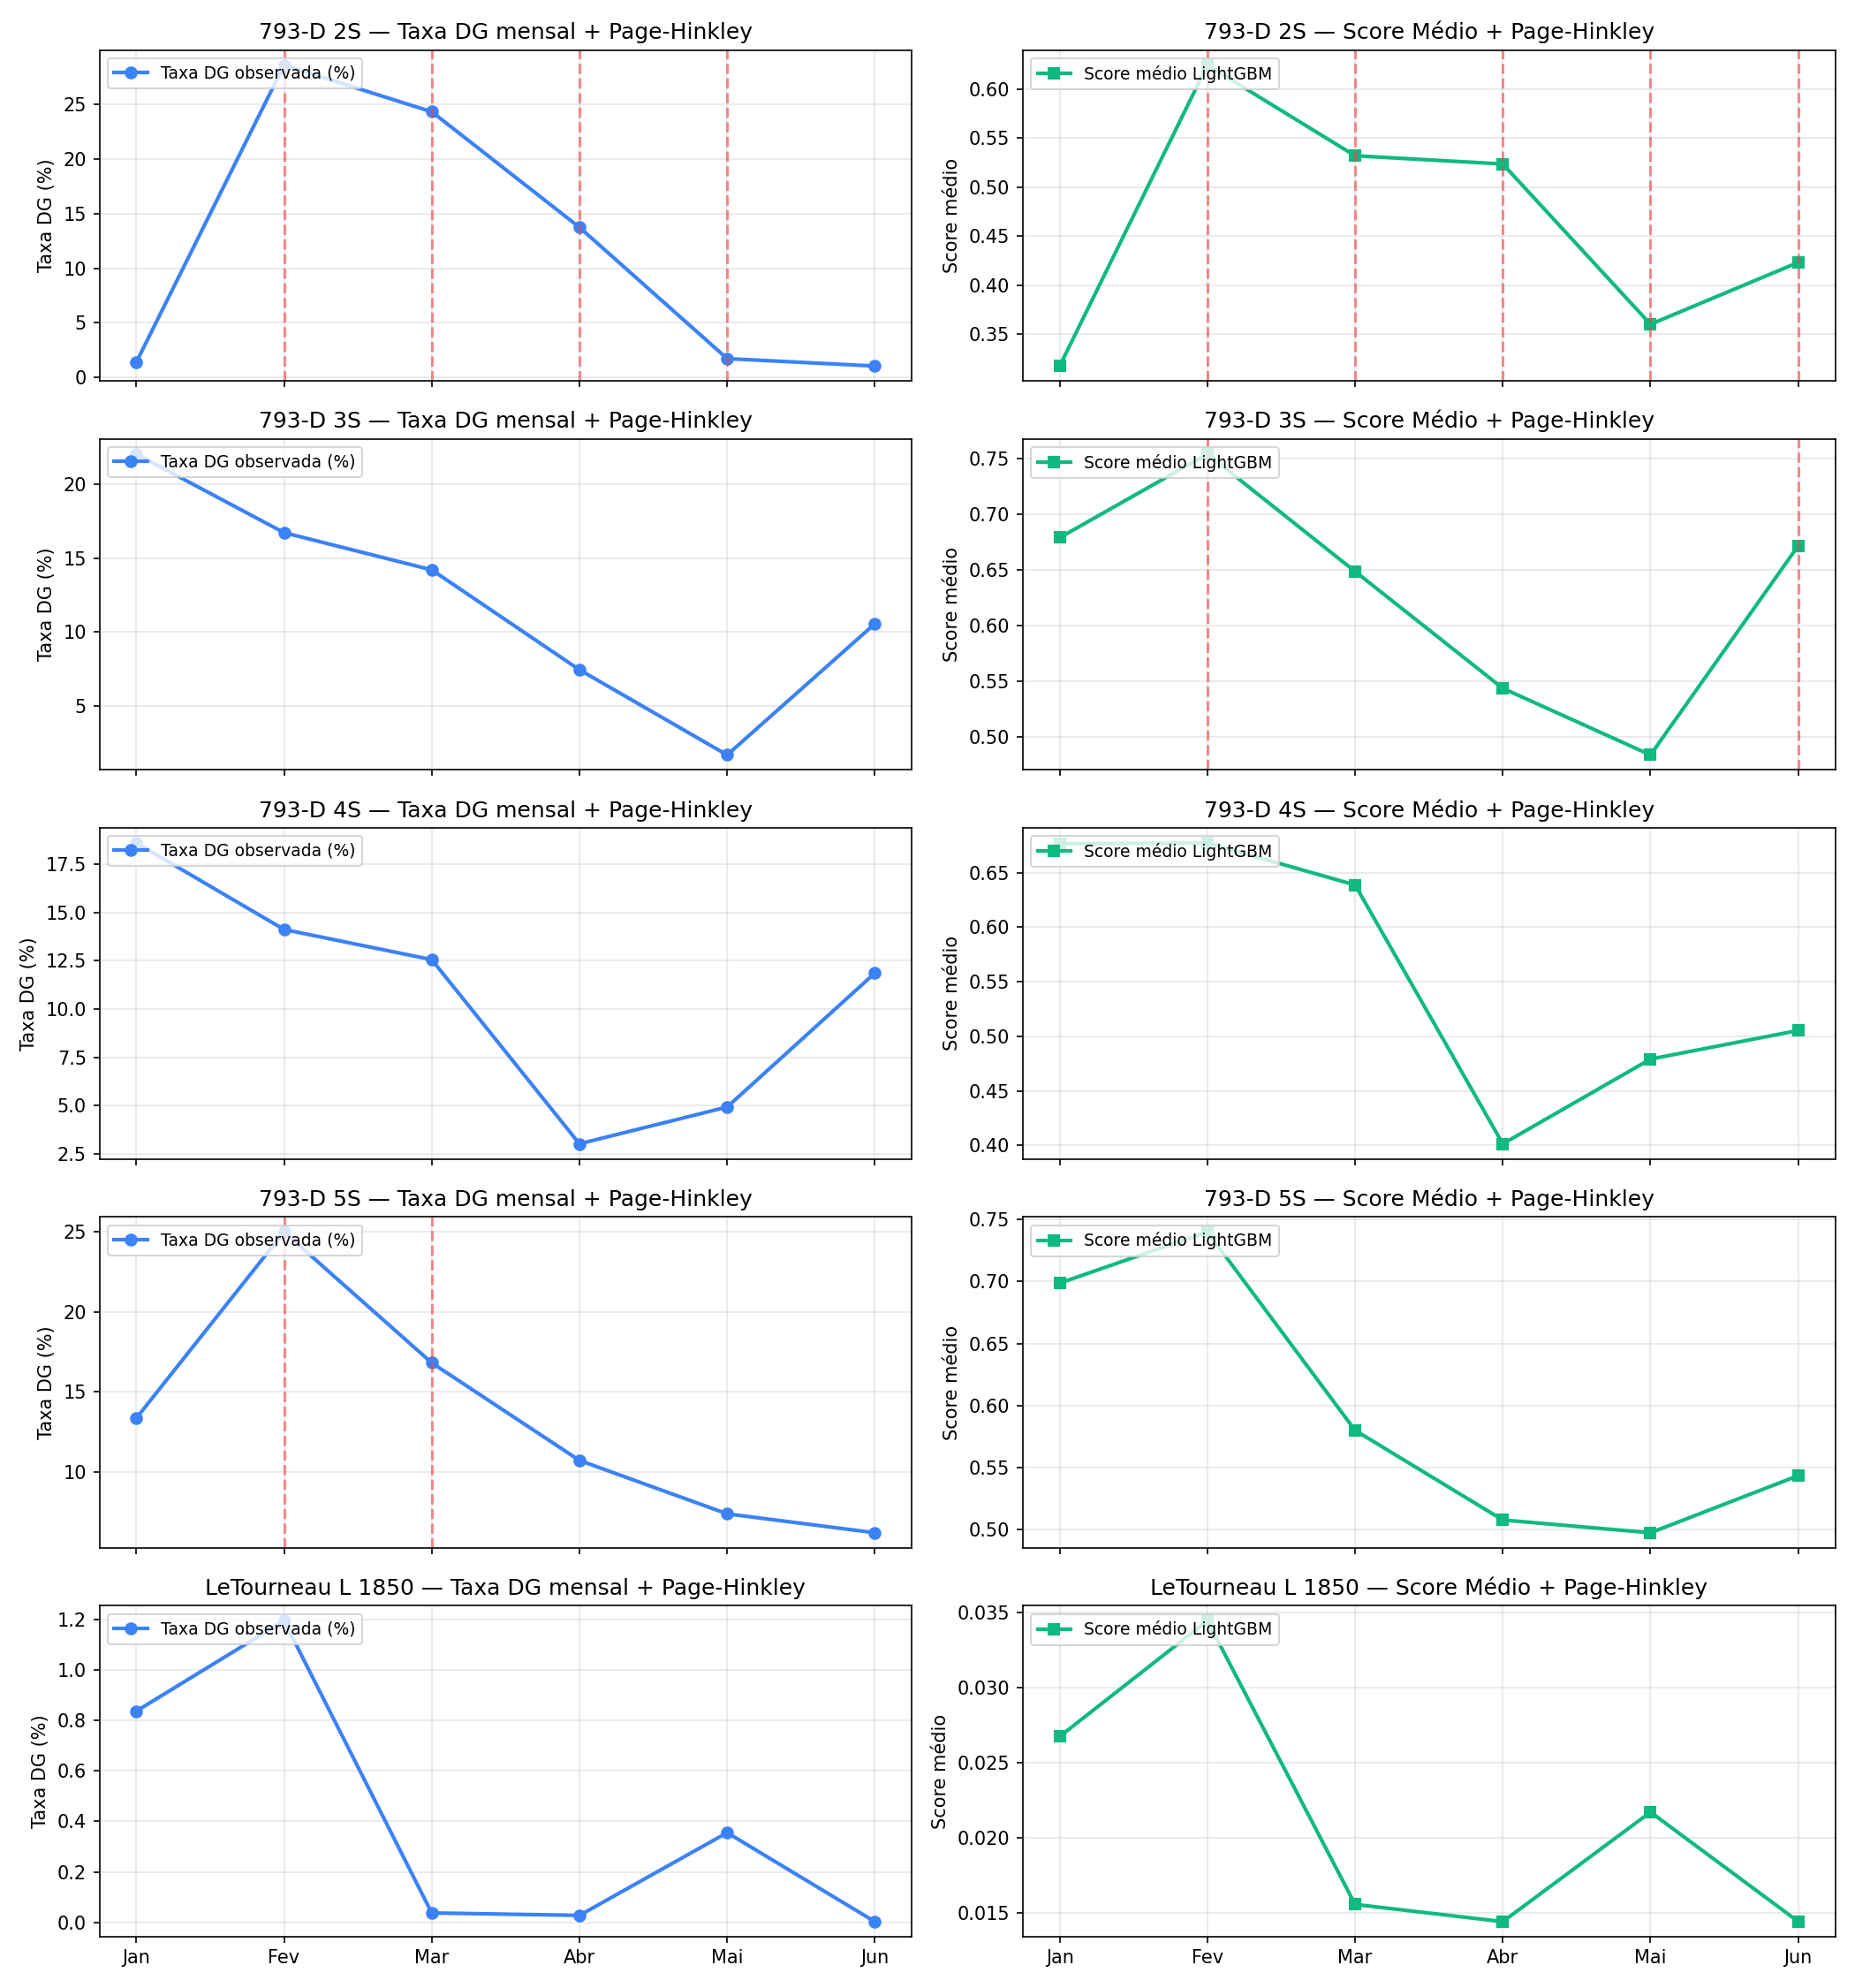

In [3]:
display(Image(filename=str(fig_dir / 'drift_detection_by_fleet.png')))

### Leitura por frota

- **793-D 2S:** alta volatilidade. Taxa DG varia de 1,4% (Jan) → 28,6% (Fev) → 24,3% (Mar) → 13,7% (Abr) → 1,7% (Mai). Detector dispara em quase todos os meses — frota com perfil operacional instável.
- **793-D 3S:** drift detectado no score em Fev e Jun mas não na taxa observada — modelo "sente" mudanças que ainda não se materializaram em taxa.
- **793-D 4S:** estável. Sem drift detectado — frota com perfil de risco mais previsível.
- **793-D 5S:** drift em Fev e Mar — período de instabilidade que coincide com o pico geral de DG da frota.
- **LeTourneau L 1850:** **detector silencioso, apesar de variação de 600× na taxa**. Achado metodológico importante (próxima seção).

## 3. KS-Test entre Meses Consecutivos

O KS test detecta mudança de **forma** da distribuição de scores, não só da média. Útil para drift sutil — quando a média se mantém mas a cauda muda.

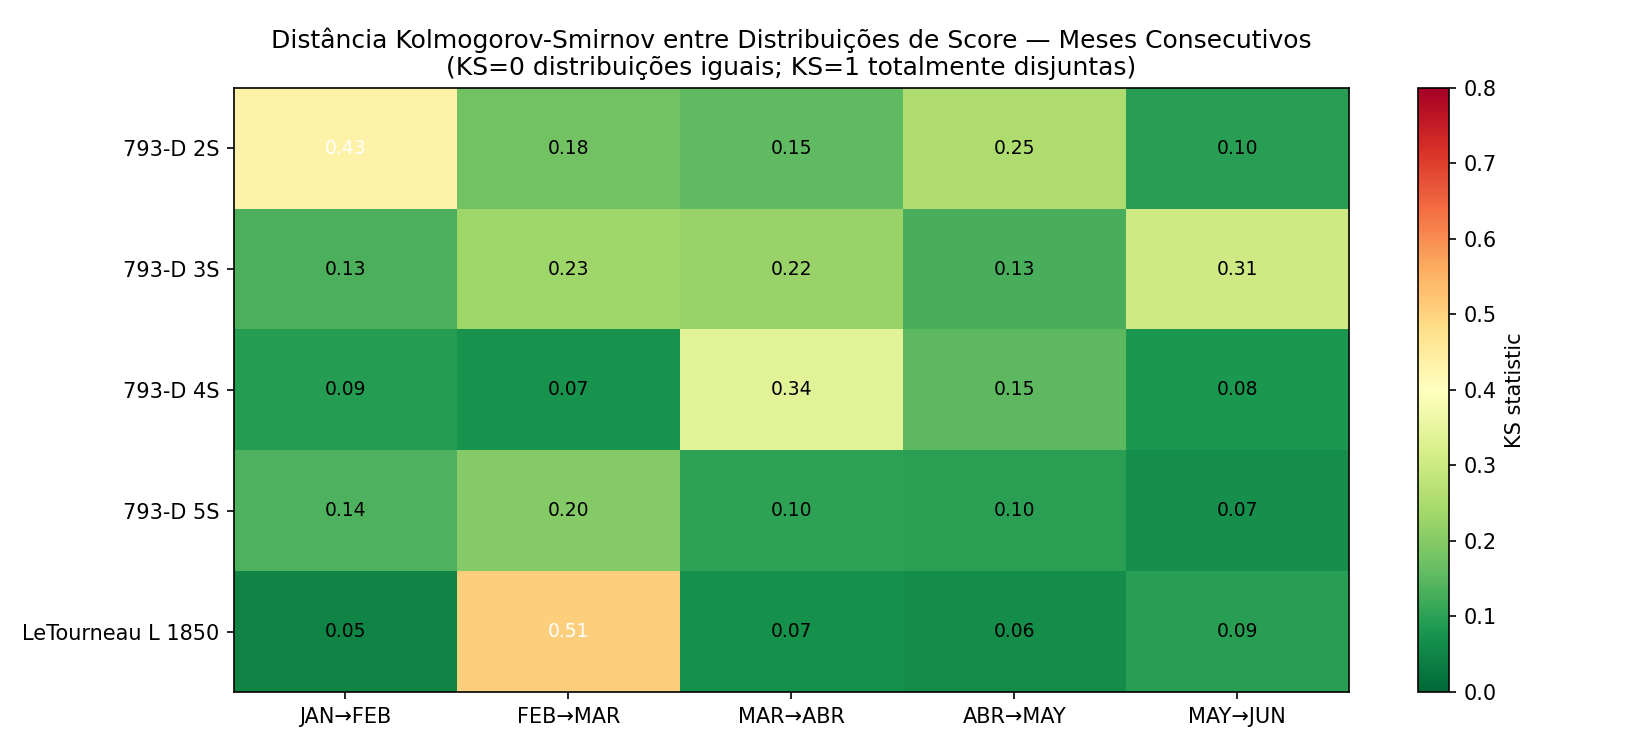

In [4]:
display(Image(filename=str(fig_dir / 'drift_ks_heatmap.png')))

O heatmap mostra que **toda transição mensal apresenta KS > 0,1** — distribuições de score nunca são iguais entre meses. Em produção, KS > 0,3 (regiões em vermelho) deveria disparar análise; KS > 0,5 deveria disparar re-treino imediato.

## 4. Achado Metodológico — Falha do Detector na Escavadeira

O Page-Hinkley com threshold absoluto **subestima drift em classes raras**. A taxa DG da escavadeira variou de 0,002% (Jun) a 1,20% (Fev) — fator de 600×, mas a variação em pontos percentuais é menor que λ=0,02 (2 pp), então o detector permanece silencioso.

**Implicações práticas:**

1. **Detecção sensível à escala:** classes minoritárias precisam de detector com threshold relativo ou em escala log.
2. **Combinar detectores:** Page-Hinkley sobre taxa + KS sobre distribuição de score detecta cenários complementares.
3. **Threshold adaptativo por frota:** classes raras precisam λ menor — sugestão: λ_fleet = max(0,005, base_rate × 5).

Implementação refinada para produção:

```python
def adaptive_threshold(base_rate, min_lambda=0.005, factor=5.0):
    return max(min_lambda, base_rate * factor)

# Page-Hinkley com threshold por frota
lambda_2s = adaptive_threshold(0.10)   # = 0.5
lambda_esc = adaptive_threshold(0.006) # = 0.03 — captura variações na escavadeira
```

## 5. Recomendação para Produção

1. **Pipeline diário:** rodar Page-Hinkley + KS test ao final de cada dia operacional sobre janela rolante de 30 dias por frota.
2. **Alertas escalonados:**
   - KS > 0,3 entre janelas: alerta amarelo (revisar dashboard)
   - PH dispara: alerta laranja (avaliar re-treino)
   - KS > 0,5 sustentado por 7+ dias: alerta vermelho (re-treinar e re-implantar)
3. **Re-treinamento automatizado:** com critério de drift atingido, rodar o pipeline ETL completo (Bronze → Silver → Gold) com janela atualizada, re-treinar LightGBM, re-calibrar Isotonic, validar contra holdout, promover novo modelo se F1 ≥ baseline.
4. **Monitoramento contínuo:** persistir scores em data warehouse para auditoria; criar dashboard de drift no Streamlit ou Grafana com visualização de Page-Hinkley em tempo real.